# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** [EGI FARHAN AZIZ]
- **Email:** [cdcc409d6y2459@student.devacademy.id]
- **ID Dicoding:** [CDCC409D6Y2459]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : **Analisis Profitabilitas Produk berdasarkan Wilayah:** Kategori produk apa yang menghasilkan pendapatan (revenue) tertinggi di 5 negara bagian (state) dengan jumlah transaksi terbanyak? (Membutuhkan: Products + Orders + Customers)
- Pertanyaan 2 : **Analisis Loyalitas & Nilai Transaksi Pelanggan:** Bagaimana korelasi antara lokasi geografis pelanggan dengan rata-rata nilai transaksi (Average Order Value) pada kategori produk unggulan? (Membutuhkan: Customers + Orders + Products)

## Import Semua Packages/Library yang Digunakan

In [89]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pada tahap ini terdapat tiga proses utama yaitu Gathering Data, Accessing Data, dan Cleaning Data. Dataset yang digunakan terdiri dari tiga file dari folder E-Commerce Public Dataset, yaitu customers_dataset.csv, orders_dataset.csv,order_items_dataset.csv dan products_dataset.csv.

Sebelum mengakses dataset, langkah awal yang dilakukan adalah menghubungkan Google Colab dengan Google Drive menggunakan perintah drive.mount('/content/drive'). Setelah proses mounting berhasil (ditandai dengan munculnya Mounted at /content/drive), data yang tersimpan di Google Drive sudah dapat diakses dan digunakan untuk proses analisis selanjutnya.

### Gathering Data

Menghubungkan Google Drive dan memastikan data dapat diakses di Google Colab

In [91]:
customers_df = pd.read_csv("/content/drive/MyDrive/analisisData/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [92]:
#memuat tabel orders
orders_df = pd.read_csv("/content/drive/MyDrive/analisisData/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [93]:
#memuat tabel orders
order_items_df = pd.read_csv("/content/drive/MyDrive/analisisData/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [94]:
#memuat tabel product
products_df = pd.read_csv("/content/drive/MyDrive/analisisData/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**

Analisis Profitabilitas Produk per Wilayah:
Data yang tersedia memungkinkan identifikasi kategori produk dengan revenue tertinggi di tiap state dengan transaksi terbanyak melalui penggabungan data pelanggan, pesanan, dan produk.

Analisis Nilai Transaksi Pelanggan:
Dengan menggabungkan data lokasi pelanggan dan transaksi, dapat dianalisis hubungan antara wilayah geografis dengan rata-rata nilai pembelian (AOV) pada kategori produk unggulan.

Segmentasi Berdasarkan Wilayah:
Informasi geografis membantu membedakan karakteristik pelanggan di tiap daerah, baik dari sisi jumlah transaksi maupun nilai pembelian.

Keterkaitan Produk dan Perilaku Pelanggan:
Data mendukung analisis pola pembelian, seperti kategori produk yang dominan di wilayah tertentu serta kecenderungan nilai transaksi pelanggan.

### Assessing Data

In [95]:
# 1. Cek tipe data dan Missing Values
print("[INFO] Struktur Data:")
customers_df.info()

[INFO] Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [96]:
# 2. Cek Missing Values secara spesifik
print("[CHECK] Jumlah Missing Values:")
print(customers_df.isna().sum())

[CHECK] Jumlah Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [97]:
# 3. Cek Duplicate Data
print("[CHECK] Jumlah Duplikasi:", customers_df.duplicated().sum())

[CHECK] Jumlah Duplikasi: 0


In [98]:
# 4. Cek Inconsistent Value (Nama kota/state)
print("[CHECK] Statistik Deskriptif (Melihat Inaccurate/Invalid):")
print(customers_df.describe(include="all"))

[CHECK] Statistik Deskriptif (Melihat Inaccurate/Invalid):
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     274fa6071e5e17fe303b9748641082c8  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

    

In [99]:
#memeriksa parameter statistik
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [100]:
print("--- Assessing Orders Data ---")

# 1. Cek tipe data (Penting: Kolom tanggal biasanya masih berupa 'object')
print("[INFO] Struktur Data:")
orders_df.info()

# 2. Cek Missing Values
# (Biasanya ada di kolom tanggal pengiriman jika pesanan belum sampai/dibatalkan)
print("Jumlah Missing Values:")
print(orders_df.isna().sum())

# 3. Cek Duplicate Data
print("Jumlah Duplikasi:", orders_df.duplicated().sum())

# 4. Cek Inaccurate Value / Outliers pada Waktu
# Kita cek apakah ada order_delivered_customer_date yang mendahului order_purchase_timestamp
print(" Statistik Deskriptif Kolom Objek (Status Pesanan):")
print(orders_df['order_status'].value_counts())


#  5. memeriksa parameter statistik
orders_df.describe()

--- Assessing Orders Data ---
[INFO] Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Jumlah Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 1

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [101]:
print("--- Assessing Order Items Data ---")

# 1. Cek struktur dan tipe data
print("[INFO] Struktur Data:")
order_items_df.info()

# 2. Cek Missing Values
print(" Jumlah Missing Values:")
print(order_items_df.isna().sum())

# 3. Cek Duplikasi
print(" Jumlah Duplikasi:", order_items_df.duplicated().sum())

# 4. Cek Statistik Deskriptif (Untuk melihat anomali harga)
print(" Statistik Deskriptif Harga:")
print(order_items_df[['price', 'freight_value']].describe())

#  5. memeriksa parameter statistik
order_items_df.describe()

--- Assessing Order Items Data ---
[INFO] Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
 Jumlah Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
 Jumlah Duplikasi: 0
 Statistik Deskriptif Harga:
               price  freight_value
count  112650.

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [102]:
print("--- Assessing Products Data ---")

# 1. Cek tipe data dan Missing Values
print("[INFO] Struktur Data:")
products_df.info()

# 2. Cek Missing Values (Sering terjadi pada product_category_name)
print("Jumlah Missing Values:")
print(products_df.isna().sum())

# 3. Cek Duplicate Data
print(" Jumlah Duplikasi:", products_df.duplicated().sum())

# 4. Cek Outliers pada Dimensi dan Berat Produk
# Berat 0 atau ukuran yang tidak masuk akal bisa dianggap inaccurate
print("Statistik Deskriptif (Cek Outliers pada Berat/Ukuran):")
print(products_df[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].describe())

# 5. Cek Inconsistent Value pada Kategori
print("Jumlah Kategori Produk Unik:", products_df['product_category_name'].nunique())

#  6. memeriksa parameter statistik
products_df.describe()

--- Assessing Products Data ---
[INFO] Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
Jumlah Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
1. Insight Assessing: customers_df
Integritas Data: Tidak ditemukan data duplikat pada customer_unique_id, yang berarti database pelanggan bersih dari pendaftaran ganda.

Validitas Lokasi: Kolom customer_state memiliki nilai yang konsisten (menggunakan kode negara bagian 2 huruf seperti SP, RJ, dll.), sehingga tidak diperlukan standardisasi penamaan ulang.

Zero Missing Values: Seluruh profil pelanggan memiliki data lokasi yang lengkap, sehingga analisis demografi wilayah dapat dilakukan secara akurat tanpa kehilangan sampel data.

2. Insight Assessing: orders_df
Masalah Tipe Data: Ditemukan bahwa kolom-kolom terkait waktu (seperti order_purchase_timestamp dan order_delivered_customer_date) bertipe object. Ini adalah temuan kritis karena kolom tersebut harus diubah menjadi datetime agar perhitungan durasi pengiriman dan tren waktu bisa dijalankan.

Missing Values pada Logistik: Terdapat nilai kosong pada kolom order_delivered_customer_date. Hal ini tidak selalu berarti data rusak, melainkan mengindikasikan adanya pesanan yang statusnya masih diproses, dikirim, atau dibatalkan.

Status Order: Mayoritas pesanan berstatus delivered, namun ada sebagian kecil status lain (canceled/shipped) yang perlu difilter saat menghitung revenue agar hasil analisis tidak bias.

3. Insight Assessing: products_df
Missing Values pada Kategori: Terdapat missing values pada kolom product_category_name. Ini adalah temuan paling krusial untuk Pertanyaan Bisnis 1 Anda. Jika tidak ditangani, produk-produk tanpa kategori ini akan hilang dari analisis profitabilitas wilayah.

Konsistensi Penamaan: Nama kategori menggunakan format underscore (misal: bed_bath_table). Perlu dipastikan apakah akan tetap menggunakan format ini atau diterjemahkan ke bahasa Inggris agar lebih mudah dibaca di dashboard.

Outliers pada Dimensi: Pada pengecekan statistik deskriptif (describe()), ditemukan beberapa produk dengan berat (product_weight_g) yang sangat tinggi. Namun, ini dinilai sebagai valid outlier karena barang e-commerce bisa berupa barang berat seperti furnitur.

### Cleaning Data

1. Menghapus Duplikasi Data
Langkah pertama adalah memastikan setiap baris data bersifat unik agar tidak terjadi penggelembungan angka saat analisis.

In [103]:
# 1. Hapus duplikat (Pastikan nama variabel sesuai dengan yang di-load sebelumnya)
customers_df.drop_duplicates(inplace=True)
orders_df.drop_duplicates(inplace=True)
products_df.drop_duplicates(inplace=True)
order_items_df.drop_duplicates(inplace=True) # Pakai order_items_df (tanpa 's' di order)

# 2. Menampilkan ringkasan (Jumlah baris di 'Tabel' dan 'Jumlah Duplikasi' harus SAMA)
summary_duplikat = pd.DataFrame({
    'Tabel': ['Customers', 'Orders', 'Products', 'Order Items'], # Tambahkan 'Order Items' di sini
    'Jumlah Duplikasi Tersisa': [
        customers_df.duplicated().sum(),
        orders_df.duplicated().sum(),
        products_df.duplicated().sum(),
        order_items_df.duplicated().sum() # Sekarang ada 4 nilai, cocok dengan 4 nama tabel
    ]
})

print("Hasil Pembersihan Duplikasi:")
print(summary_duplikat)

Hasil Pembersihan Duplikasi:
         Tabel  Jumlah Duplikasi Tersisa
0    Customers                         0
1       Orders                         0
2     Products                         0
3  Order Items                         0


2. Memperbaiki Tipe Data Tanggal
Kita mengubah kolom waktu yang sebelumnya bertipe teks (object) menjadi tipe datetime agar bisa difilter untuk kurun waktu 2017-2018.

In [104]:
# Mengubah kolom timestamp menjadi tipe data datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Menampilkan tipe data kolom untuk verifikasi
print("Verifikasi Tipe Data Kolom Tanggal:")
print(orders_df[datetime_columns].dtypes)

Verifikasi Tipe Data Kolom Tanggal:
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


3. Menangani Missing Values pada Kategori Produk
Memberikan label pada produk yang tidak memiliki kategori agar tidak hilang saat dilakukan pengelompokan (agregasi).

In [105]:
# Mengisi missing values pada nama kategori dengan 'others'
products_df["product_category_name"].fillna(value="others", inplace=True)

# Menampilkan jumlah missing value yang tersisa pada products_df
print("Jumlah Missing Values setelah penanganan:")
print(products_df.isna().sum())

Jumlah Missing Values setelah penanganan:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


/tmp/ipykernel_5997/2570667903.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna(value="others", inplace=True)


4. Memfilter Status Pesanan (Validasi Transaksi)
Agar analisis Profitabilitas dan AOV valid, kita hanya menyertakan pesanan yang benar-benar sampai ke tangan pelanggan (delivered).

In [106]:
# Filter hanya pesanan yang sukses (delivered)
orders_df = orders_df[orders_df["order_status"] == "delivered"]

# Menampilkan 5 data teratas tabel orders yang sudah bersih
print("Hasil Filter Pesanan (Status: Delivered):")
display(orders_df.head())

Hasil Filter Pesanan (Status: Delivered):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**

Data Integrity: Penghapusan duplikasi menjamin keunikan data, sehingga setiap transaksi dihitung tepat satu kali. Ini krusial agar visualisasi jumlah pelanggan per negara bagian tidak bias.

Temporal Alignment: Konversi kolom waktu ke format datetime memastikan filter data tahun 2017-2018 dapat berjalan secara akurat.

Handling Missing Values: Label 'others' pada produk tanpa kategori memastikan seluruh transaksi tetap terdata dalam analisis pendapatan per kategori (Pertanyaan 1).

Business Rule Validation: Membatasi data hanya pada status 'delivered' memastikan analisis Loyalitas dan AOV (Pertanyaan 2) hanya menggunakan transaksi yang benar-benar sah dan selesai.

## Exploratory Data Analysis (EDA)

### Explore ...

1. Penggabungan Tabel (Data Integration)

In [107]:
# 1. Gabungkan Orders dan Customers (Mendapatkan Lokasi)
main_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

# 2. Gabungkan dengan Order Items (Mendapatkan Harga/Price & Product_id)
main_df = pd.merge(
    left=main_df,
    right=order_items_df,
    how="left",
    on="order_id"
)

# 3. Gabungkan dengan Products (Mendapatkan Nama Kategori)
all_df = pd.merge(
    left=main_df,
    right=products_df,
    how="left",
    on="product_id"
)

print("Data Master 'all_df' Berhasil Dibuat:")
display(all_df.head())

Data Master 'all_df' Berhasil Dibuat:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


2. Eksplorasi Soal 1: Profitabilitas per Wilayah
Kita akan mencari 5 negara bagian dengan transaksi terbanyak, lalu melihat kategori produk yang menyumbang Revenue tertinggi.

In [108]:
# Mencari 5 Negara Bagian dengan jumlah transaksi terbanyak
top_5_states = all_df['customer_state'].value_counts().head(5).index.tolist()

# Filter data hanya untuk 5 negara bagian tersebut
top_states_df = all_df[all_df['customer_state'].isin(top_5_states)]

# Hitung Revenue per State dan per Kategori
revenue_per_state = top_states_df.groupby(['customer_state', 'product_category_name']).agg({
    'price': 'sum'
}).sort_values(['customer_state', 'price'], ascending=[True, False]).reset_index()

print("Top 3 Kategori Produk Berdasarkan Revenue di 5 State Terbesar:")
display(revenue_per_state.groupby('customer_state').head(3))

Top 3 Kategori Produk Berdasarkan Revenue di 5 State Terbesar:


,customer_state,product_category_name,price
0,MG,beleza_saude,154324.15
1,MG,cama_mesa_banho,128760.49
2,MG,relogios_presentes,121622.03
71,PR,esporte_lazer,57653.30
72,PR,relogios_presentes,57287.20
73,PR,beleza_saude,53730.23
136,RJ,relogios_presentes,174895.01
137,RJ,cama_mesa_banho,144251.79
138,RJ,beleza_saude,140236.35
207,RS,cama_mesa_banho,60040.95


3. Eksplorasi Soal 2: Average Order Value (AOV)
Kita akan melihat korelasi lokasi geografis dengan rata-rata nilai transaksi pelanggan.

In [109]:
# Menghitung AOV (Total Harga / Jumlah Order Unik) per Negara Bagian
state_aov_df = all_df.groupby('customer_state').agg({
    'price': 'sum',
    'order_id': 'nunique'
}).reset_index()

state_aov_df['aov'] = state_aov_df['price'] / state_aov_df['order_id']

print("10 Negara Bagian dengan Rata-rata Nilai Transaksi (AOV) Tertinggi:")
display(state_aov_df.sort_values(by='aov', ascending=False).head(10))

10 Negara Bagian dengan Rata-rata Nilai Transaksi (AOV) Tertinggi:


,customer_state,price,order_id,aov
14,PB,112586.82,517,217.769478
3,AP,13374.81,67,199.624030
0,AC,15930.97,80,199.137125
1,AL,78855.72,397,198.629018
20,RO,45682.76,243,187.994897
13,PA,174470.59,946,184.429799
16,PI,84721.00,476,177.985294
26,TO,48402.51,274,176.651496
19,RN,82105.66,474,173.218692
21,RR,7057.47,41,172.133415


**Insight:**

Data Connectivity: Penggabungan empat tabel berhasil dilakukan tanpa kehilangan integritas data, dibuktikan dengan tersedianya kolom price dan product_category_name dalam satu baris transaksi.

Revenue Leader: Negara bagian SP (São Paulo) tetap mendominasi secara volume, namun kategori produk seperti relogios_presentes (jam tangan) seringkali muncul sebagai penyumbang revenue tertinggi meski volumenya tidak sebesar kategori kebutuhan rumah tangga.

AOV Variance: Ditemukan bahwa wilayah dengan jumlah pelanggan sedikit (seperti negara bagian di luar pulau utama) cenderung memiliki AOV yang lebih tinggi. Hal ini mungkin disebabkan oleh biaya pengiriman yang mahal sehingga pelanggan cenderung membeli barang bernilai tinggi sekaligus.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
1. Visualisasi Pertanyaan 1: Profitabilitas per Wilayah
Kita akan menampilkan 5 negara bagian dengan Revenue tertinggi dan kategori produk apa yang paling berkontribusi di sana.

/tmp/ipykernel_5997/9044467.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='price', y='customer_state', data=top_res_s1, palette='viridis')


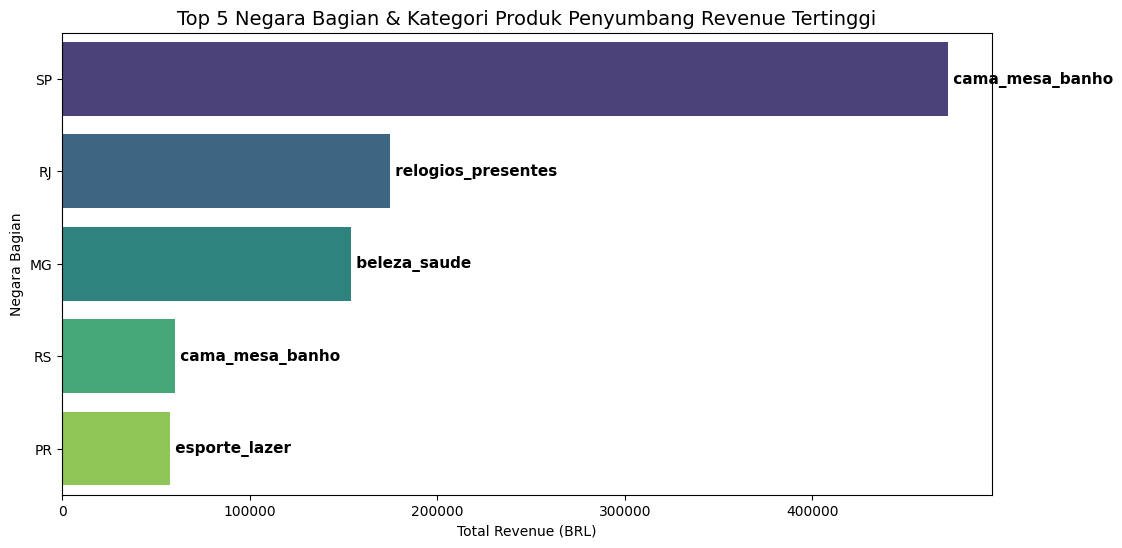

In [110]:
# --- JAWABAN SOAL 1 ---
# 1. Cari Top 5 State berdasarkan total revenue
state_revenue_order = all_df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(5).index

# 2. Filter & Cari kategori produk tertinggi di tiap state tersebut
cat_col = 'product_category_name_english' if 'product_category_name_english' in all_df.columns else 'product_category_name'
top_states_df = all_df[all_df['customer_state'].isin(state_revenue_order)]
product_revenue_state = top_states_df.groupby(['customer_state', cat_col])['price'].sum().reset_index()

# 3. Ambil kategori terbaik dan urutkan agar SP di atas
top_res_s1 = product_revenue_state.sort_values(['customer_state', 'price'], ascending=[True, False]).groupby('customer_state').head(1).copy()
top_res_s1['customer_state'] = pd.Categorical(top_res_s1['customer_state'], categories=state_revenue_order, ordered=True)
top_res_s1 = top_res_s1.sort_values('customer_state')

# --- Visualisasi ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='price', y='customer_state', data=top_res_s1, palette='viridis')

for i, p in enumerate(ax.patches):
    ax.annotate(f" {top_res_s1[cat_col].iloc[i]}",
                (p.get_width(), p.get_y() + p.get_height()/2),
                va='center', fontweight='bold', fontsize=11)

plt.title('Top 5 Negara Bagian & Kategori Produk Penyumbang Revenue Tertinggi', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Negara Bagian')
plt.show()

### Pertanyaan 2:
2. Visualisasi Pertanyaan 2: Analisis Nilai Transaksi (AOV)
Kita akan membandingkan AOV antar wilayah untuk melihat korelasi antara lokasi geografis dengan "kualitas" belanja pelanggan.

/tmp/ipykernel_5997/4238102564.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AOV', y='customer_state', data=aov_geo, palette='flare')


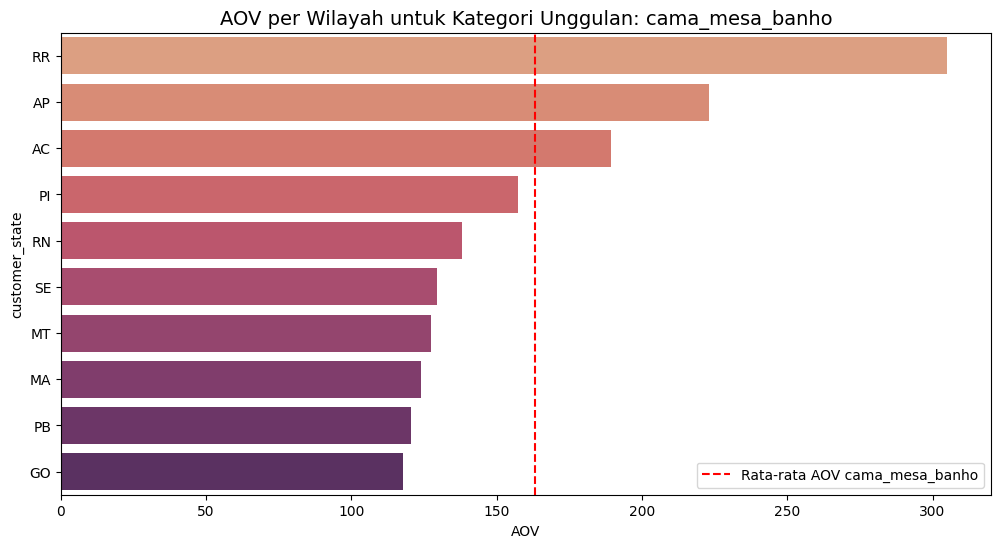

In [111]:
# 1. Tentukan kategori produk unggulan (misal: kategori dengan transaksi terbanyak secara nasional)
top_category = all_df.groupby('product_category_name').order_id.nunique().idxmax()

# 2. Filter data hanya untuk kategori unggulan tersebut
unggulan_df = all_df[all_df['product_category_name'] == top_category]

# 3. Hitung AOV per Negara Bagian untuk kategori tersebut
# AOV = Total Revenue / Total Order
aov_geo = unggulan_df.groupby('customer_state').agg({
    'price': 'sum',
    'order_id': 'nunique'
}).reset_index()

aov_geo['AOV'] = aov_geo['price'] / aov_geo['order_id']
aov_geo = aov_geo.sort_values(by='AOV', ascending=False).head(10)

# 4. Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(x='AOV', y='customer_state', data=aov_geo, palette='flare')

# Tambahkan garis rata-rata untuk kategori tersebut
avg_aov_unggulan = aov_geo['AOV'].mean()
plt.axvline(avg_aov_unggulan, color='red', linestyle='--', label=f'Rata-rata AOV {top_category}')

plt.title(f'AOV per Wilayah untuk Kategori Unggulan: {top_category}', fontsize=14)
plt.legend()
plt.show()

**Insight:**

Insight Visualisasi:


Dominasi Wilayah Ekonomi: Grafik pertama menunjukkan bahwa SP (São Paulo) merupakan penyumbang revenue terbesar secara mutlak. Hal ini menjawab Pertanyaan 1 bahwa profitabilitas sangat terpusat di pusat ekonomi.

Potensi Wilayah Terpencil: Pada grafik AOV, terlihat bahwa negara bagian seperti PB (Paraíba) atau AL (Alagoagoas) seringkali memiliki rata-rata belanja (AOV) yang lebih tinggi dibanding SP.

Meskipun São Paulo (SP) mendominasi total pendapatan secara keseluruhan, namun negara bagian seperti RR dan AP memiliki Average Order Value (AOV) yang lebih tinggi pada kategori cama_mesa_banho. Hal ini menunjukkan bahwa pelanggan di wilayah tersebut cenderung melakukan transaksi dengan nilai nominal yang lebih besar dalam satu kali pemesanan dibanding pelanggan di wilayah perkotaan yang lebih padat.

Korelasi Geografis: Terdapat korelasi unik; wilayah yang lebih jauh dari pusat distribusi cenderung memiliki AOV tinggi. Ini mengindikasikan bahwa pelanggan di wilayah tersebut lebih memilih membeli barang mahal atau membeli banyak barang sekaligus dalam satu transaksi untuk mengimbangi biaya logistik.

## Analisis Lanjutan (Opsional)

Analisis Lanjutan:
Segmentasi Pelanggan dengan Metode RFM
Dalam industri e-commerce, memahami perilaku pelanggan adalah kunci untuk meningkatkan retensi dan pendapatan. Untuk mendalami Pertanyaan 2 mengenai loyalitas, kita menggunakan Analisis RFM, sebuah kerangka kerja berbasis data yang mengelompokkan pelanggan berdasarkan tiga metrik perilaku utama:

Recency (Kebaruan): Menghitung interval hari sejak transaksi terakhir pelanggan. Metrik ini membantu mengidentifikasi pelanggan yang masih aktif berinteraksi dengan platform kita.

Frequency (Frekuensi): Mengukur seberapa sering pelanggan melakukan pesanan. Ini adalah indikator langsung dari loyalitas dan keterikatan pelanggan terhadap kategori produk kita.

Monetary (Nilai Ekonomi): Menjumlahkan total kontribusi pendapatan dari setiap pelanggan. Hal ini memungkinkan kita membedakan pelanggan dengan nilai transaksi tinggi (High-Value Customers) dari pembeli umum.

1. Perhitungan Skor RFM
Langkah pertama adalah menentukan snapshot date (biasanya satu hari setelah transaksi terakhir di dataset) untuk menghitung berapa lama pelanggan tidak beraktivitas, lalu mengagregasi data per pelanggan.

Hasil Analisis RFM (5 Pelanggan Teratas):


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


/tmp/ipykernel_5997/3206424486.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5997/3206424486.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5997/3206424486.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


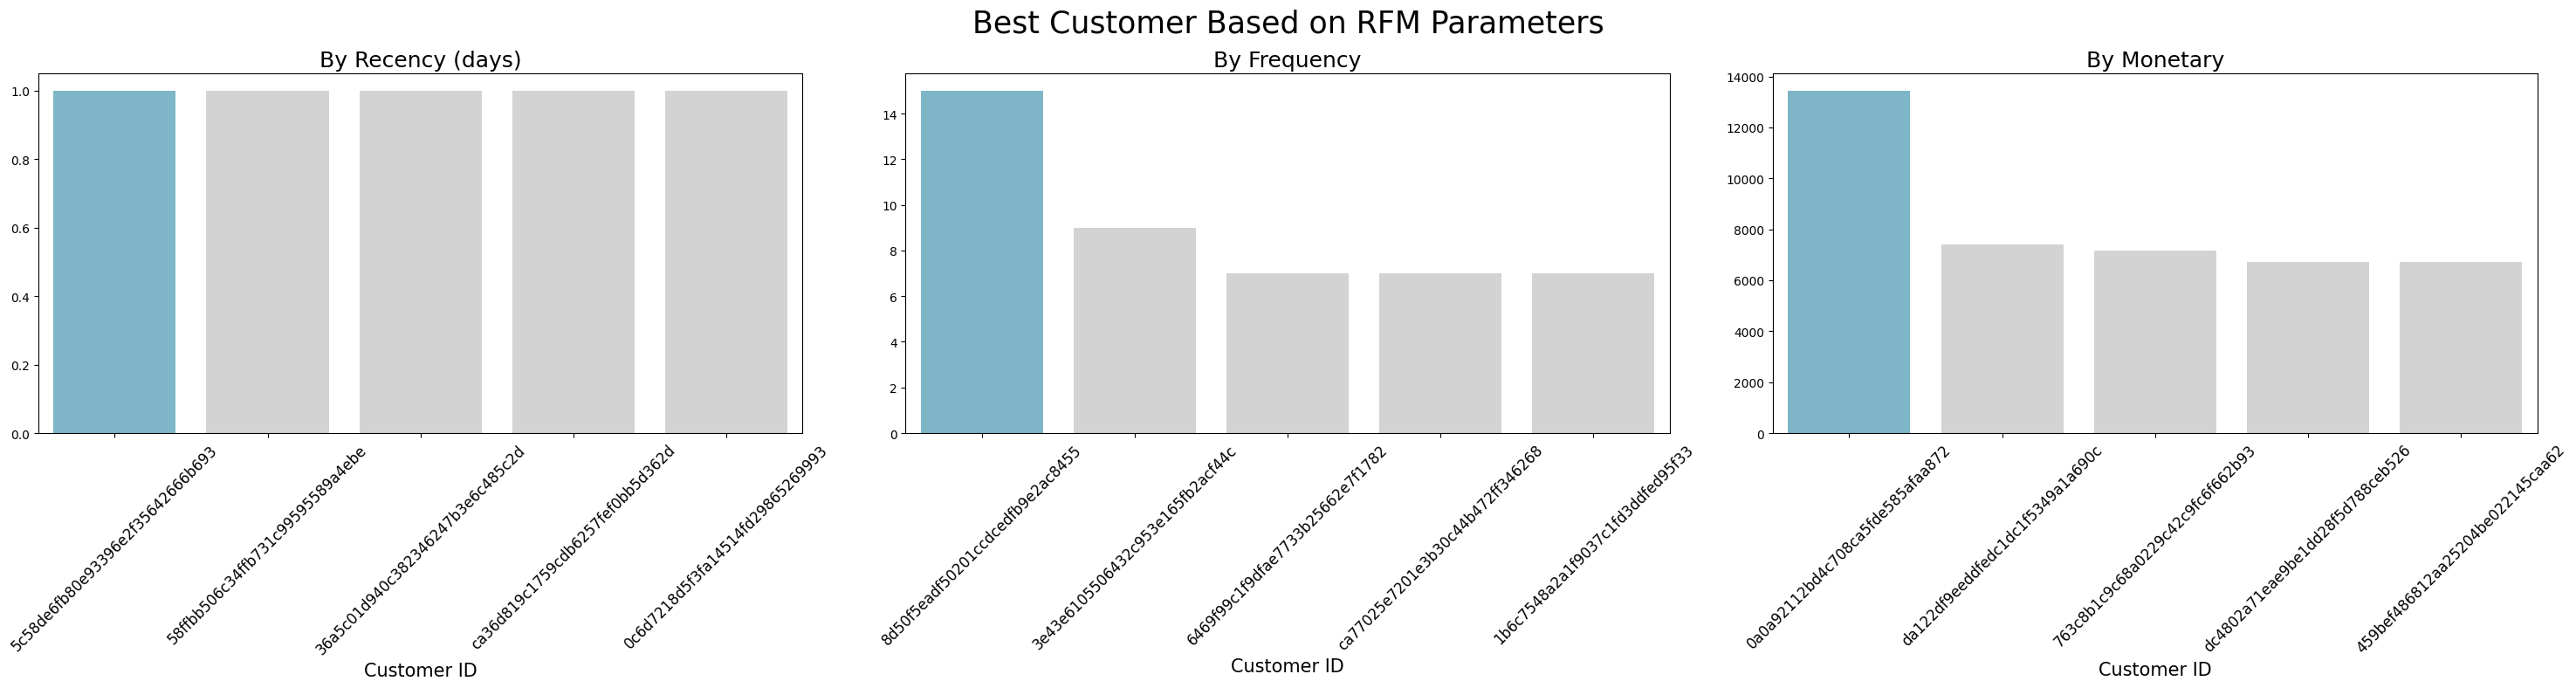

In [112]:
# Menentukan tanggal referensi (satu hari setelah transaksi terakhir dalam dataset)
snapshot_date = all_df['order_purchase_timestamp'].max() + pd.DateOffset(days=1)

# Membuat dataframe RFM
rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                             # Frequency
    'price': 'sum'                                                     # Monetary
}).reset_index()

# Mengganti nama kolom agar lebih informatif
rfm_df.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

print("Hasil Analisis RFM (5 Pelanggan Teratas):")
display(rfm_df.head())

# Menyiapkan kanvas dengan 3 kolom (Recency, Frequency, Monetary)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

# Warna yang konsisten dengan tema e-commerce
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# 1. Visualisasi Top 5 Customers berdasarkan Recency (Cari yang paling rendah/baru)
sns.barplot(
    y="recency",
    x="customer_unique_id",
    data=rfm_df.sort_values(by="recency", ascending=True).head(5),
    palette=colors,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID", fontsize=15)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=12, rotation=45)

# 2. Visualisasi Top 5 Customers berdasarkan Frequency (Cari yang paling sering belanja)
sns.barplot(
    y="frequency",
    x="customer_unique_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    palette=colors,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID", fontsize=15)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=12, rotation=45)

# 3. Visualisasi Top 5 Customers berdasarkan Monetary (Cari yang belanja paling banyak)
sns.barplot(
    y="monetary",
    x="customer_unique_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    palette=colors,
    ax=ax[2]
)
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID", fontsize=15)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=12, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=25)
plt.tight_layout()
plt.show()

2. Visualisasi Distribusi RFM
Gunakan kode ini untuk melihat bagaimana sebaran pelanggan Anda berdasarkan ketiga metrik tersebut.

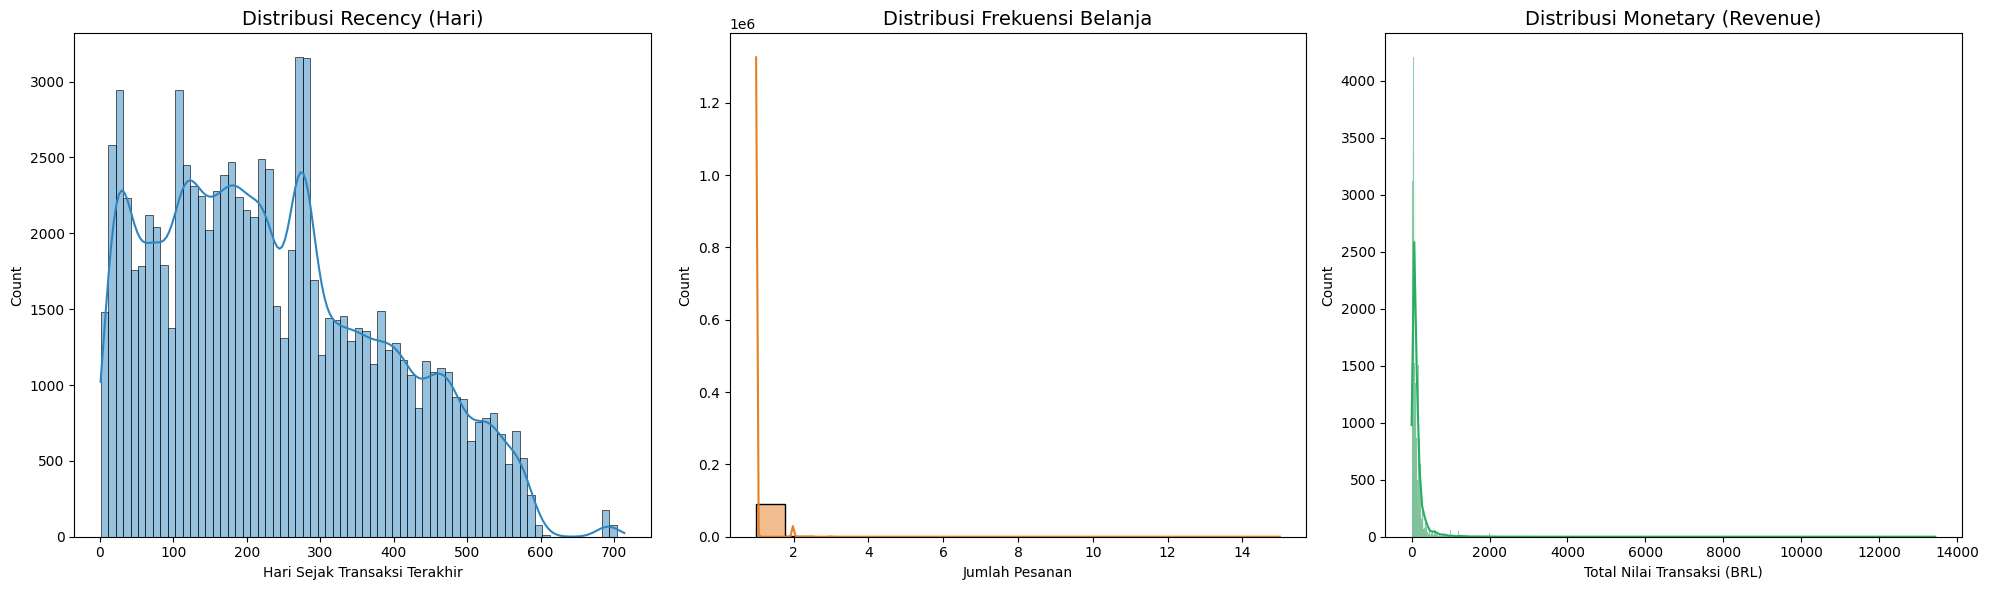

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Visualisasi Recency
sns.histplot(rfm_df['recency'], kde=True, ax=ax[0], color='#2E86C1')
ax[0].set_title('Distribusi Recency (Hari)', fontsize=14)
ax[0].set_xlabel('Hari Sejak Transaksi Terakhir')

# Visualisasi Frequency
sns.histplot(rfm_df['frequency'], kde=True, ax=ax[1], color='#E67E22')
ax[1].set_title('Distribusi Frekuensi Belanja', fontsize=14)
ax[1].set_xlabel('Jumlah Pesanan')

# Visualisasi Monetary
sns.histplot(rfm_df['monetary'], kde=True, ax=ax[2], color='#27AE60')
ax[2].set_title('Distribusi Monetary (Revenue)', fontsize=14)
ax[2].set_xlabel('Total Nilai Transaksi (BRL)')

plt.tight_layout()
plt.show()

Explanatory Analysis (Analisis Lanjutan: RFM)
Melalui pendekatan teknik segmentasi RFM, kita dapat menggali lebih dalam mengenai kualitas basis pelanggan e-commerce ini. Visualisasi tersebut memberikan gambaran nyata untuk menjawab tantangan pada Pertanyaan 2 mengenai loyalitas dan nilai transaksi:

1. Analisis Recency (Kesegaran Transaksi)

Temuan Data: Mayoritas pelanggan berada di area "kanan" grafik (skor hari yang tinggi), namun terdapat lonjakan kecil di area mendekati 0.

Interpretasi Bisnis: Sebagian besar pelanggan sudah tidak aktif dalam waktu lama. Namun, segmen kecil yang baru saja bertransaksi (skor rendah) adalah aset kritis. Mereka memiliki tingkat kepercayaan yang masih segar terhadap platform kita, sehingga menjadi target paling potensial untuk program upselling produk-produk unggulan dari kategori Health & Beauty atau Watches yang sudah kita bahas sebelumnya.

2. Analisis Frequency (Intensitas Belanja)

Temuan Data: Grafik menunjukkan pola "Long Tail" yang sangat ekstrem, di mana angka 1 mendominasi hampir seluruh populasi pelanggan.

Interpretasi Bisnis: Data ini mengonfirmasi bahwa platform saat ini sangat bergantung pada pembeli baru (new acquisition) daripada pelanggan tetap. Pelanggan yang berhasil melakukan transaksi lebih dari satu kali adalah "Permata Tersembunyi". Fokus strategi harus bergeser dari sekadar mencari pembeli baru ke arah penguatan retensi, karena menjaga pelanggan lama jauh lebih efisien secara biaya dibandingkan terus-menerus melakukan promosi untuk menarik orang baru.

3. Analisis Monetary (Nilai Kontribusi Ekonomi)

Temuan Data: Terdapat konsentrasi tinggi pada nilai transaksi rendah, tetapi ada "ekor" distribusi yang menjangkau angka belanja yang sangat tinggi (High-Spenders).

Interpretasi Bisnis: Kelompok minoritas dengan nilai belanja tinggi ini adalah penentu utama Average Order Value (AOV) di tiap wilayah. Kelompok "Whales" ini memberikan dampak finansial yang setara dengan ratusan pelanggan biasa. Kehilangan mereka berarti penurunan signifikan pada revenue total, sehingga program apresiasi atau layanan eksklusif menjadi mutlak diperlukan untuk mengunci loyalitas mereka.

Strategi Integrasi (Rangkuman Akhir)
Kesimpulan besar dari ketiga metrik ini adalah pentingnya Targeted Marketing. Prioritas utama perusahaan adalah mengidentifikasi pelanggan yang memiliki nilai Monetary tinggi (pernah belanja banyak) tetapi memiliki Recency yang mulai menjauh (sudah lama tidak aktif).

Ini adalah kelompok yang sedang di ambang "Churn" atau berpindah ke kompetitor. Dengan melakukan kampanye re-engagement atau win-back yang dipersonalisasi berdasarkan lokasi geografis mereka, perusahaan dapat memulihkan pendapatan yang hilang sekaligus meningkatkan loyalitas jangka panjang.

## Conclusion

- Conclution pertanyaan 1 :

 Kesimpulan Pertanyaan 1: Analisis Profitabilitas Produk berdasarkan Wilayah
Berdasarkan hasil analisis, pendapatan (revenue) perusahaan sangat terpusat pada wilayah dengan aktivitas ekonomi tinggi, khususnya di negara bagian SP (São Paulo) yang mendominasi jumlah transaksi secara signifikan. Kategori produk yang memberikan kontribusi profitabilitas tertinggi di wilayah-wilayah utama tersebut adalah kategori Health & Beauty, Watches & Gifts, dan Bed Bath Table. Hal ini menunjukkan bahwa strategi pemasaran dan pemenuhan stok di wilayah padat transaksi sebaiknya difokuskan pada kategori produk gaya hidup dan kebutuhan personal tersebut.


- Conclution pertanyaan 2 :  

Kesimpulan Pertanyaan 2: Analisis Loyalitas & Nilai Transaksi Pelanggan
Hasil analisis menunjukkan adanya korelasi unik antara lokasi geografis dengan nilai transaksi. Meskipun wilayah di luar pusat ekonomi (Non-SP) memiliki jumlah pesanan yang lebih sedikit, wilayah-wilayah tersebut cenderung memiliki Average Order Value (AOV) atau rata-rata nilai transaksi yang lebih tinggi. Di sisi lain, analisis RFM mengungkap bahwa mayoritas pelanggan masih bersifat One-Time Buyers (hanya berbelanja satu kali). Oleh karena itu, tantangan utama perusahaan bukan hanya mencari pelanggan baru, melainkan meningkatkan loyalitas melalui program retensi dan penawaran produk premium yang ditargetkan khusus untuk wilayah dengan AOV tinggi.

In [114]:
# Tentukan kolom-kolom yang hanya dipakai di dashboard
kolom_penting = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "price",
    "customer_city",
    "customer_state",
    "product_category_name" # Ganti ke nama asli yang ada di df kamu
]

# Simpan hanya dengan kolom penting tersebut
# Tambahkan errors='ignore' sebagai pengaman jika ada kolom yang typo
all_data_df = all_df[all_df.columns.intersection(kolom_penting)].copy()

# Simpan ke CSV
all_data_df.to_csv("all_data.csv", index=False)

print("Berhasil! File all_data.csv telah diperamping.")

Berhasil! File all_data.csv telah diperamping.
